In [ ]:
#Assignment 2->Part B (Using MultiClass Classification)

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TensorFlow / Keras libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# Load the Glass Identification dataset

df = pd.read_csv("D:\Advanced DS\glass.csv")

# Display first five records
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
C:\Users\HP\AppData\Local\Temp\ipykernel_13656\2752134703.py:3: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("D:\Advanced DS\glass.csv")


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
# Display dataset information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Shape of Dataset: (214, 10)

Column Names:
Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB

Missing Values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Statistical Summary:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [5]:
# Display unique output categories

print("Output Categories:")
print(df['Type'].unique())

print("\nNumber of Output Classes:", df['Type'].nunique())

Output Categories:
[1 2 3 5 6 7]

Number of Output Classes: 6


In [6]:
# Convert target labels into integer values from 0 to 5

label_encoder = LabelEncoder()

df['Type'] = label_encoder.fit_transform(df['Type'])

print("Encoded Classes:")
print(df['Type'].unique())

Encoded Classes:
[0 1 2 3 4 5]


In [7]:
# Separate input and output

X = df.drop('Type', axis=1)
y = df['Type']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (214, 9)
Shape of y: (214,)


In [8]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (171, 9)
Testing Samples: (43, 9)


In [9]:
# Standardize the feature values

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Create the Artificial Neural Network

model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(6, activation='softmax'))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Display the model architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,350 (13.09 KB)

 Trainable params: 3,350 (13.09 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile the ANN model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Train the ANN model

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.1765 - loss: 1.7783 - val_accuracy: 0.2571 - val_loss: 1.7429
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3676 - loss: 1.6749 - val_accuracy: 0.4857 - val_loss: 1.6444
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4559 - loss: 1.5936 - val_accuracy: 0.4857 - val_loss: 1.5637
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4632 - loss: 1.5138 - val_accuracy: 0.4857 - val_loss: 1.4968
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4706 - loss: 1.4314 - val_accuracy: 0.4857 - val_loss: 1.4287
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4706 - loss: 1.3472 - val_accuracy: 0.4857 - val_loss: 1.3680
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4779 - loss: 1.2746 - val_accuracy: 0.4857 - val_loss: 1.3337
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4853 - loss: 1.2109 - val_accuracy: 0.4857 - val_loss: 1.3155


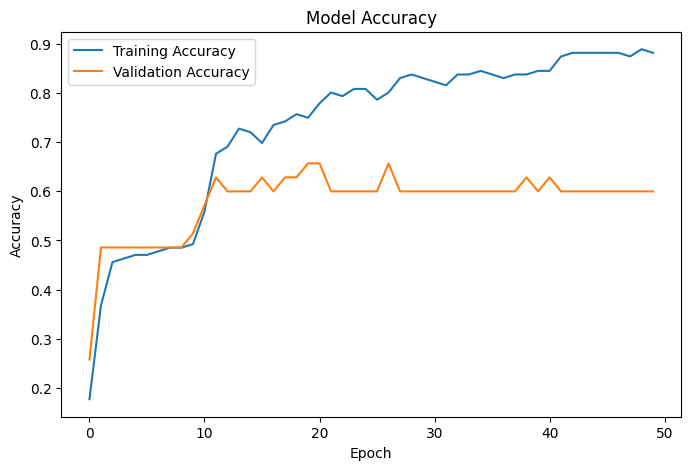

In [15]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [17]:
# Evaluate the model on testing data

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7907 - loss: 0.5623
Test Loss : 0.5622634291648865
Test Accuracy : 0.7906976938247681


In [18]:
# Predict class probabilities

y_pred_prob = model.predict(X_test)

# Convert probabilities into class labels

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted Classes:")
print(y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Predicted Classes:
[0 5 0 5 1 1 0 1 1 0 3 3 1 1 4 3 5 0 0 4 1 5 5 5 1 0 0 0 1 0 0 1 1 1 0 5 3
 0 0 1 3 5 0]


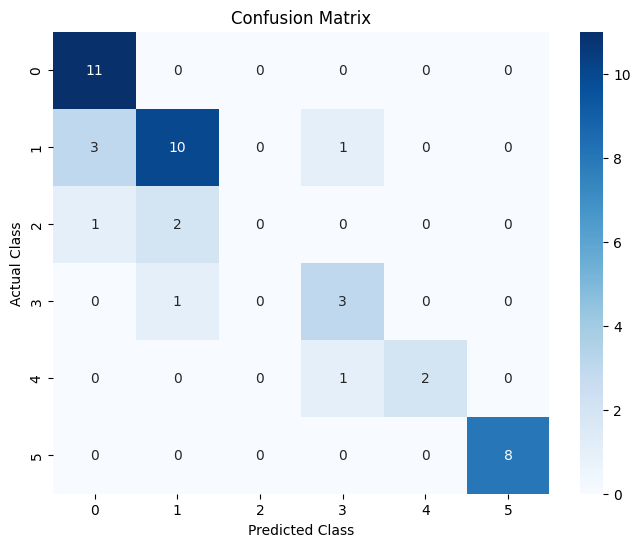

In [19]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [20]:
# Display classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       0.77      0.71      0.74        14
           2       0.00      0.00      0.00         3
           3       0.60      0.75      0.67         4
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         8

    accuracy                           0.79        43
   macro avg       0.68      0.69      0.68        43
weighted avg       0.75      0.79      0.76        43



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [21]:
# Predict the first testing sample

sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

actual_class = y_test.iloc[0]

print("Actual Class :", actual_class)
print("Predicted Class :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Actual Class : 0
Predicted Class : 0
